PythonとCartopyを用い、1997年エルニーニョ期の全球海面水温データを地理空間上に可視化した。面積比を保つモルワイデ図法を採用し、太平洋域を中心とした熱分布の広がりを定量的に表現した。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter,LongitudeFormatter
import matplotlib.ticker as mticker

In [2]:
#データ読み込み
loadfile = 'sst_OISST.npz'
#変数の抽出：海面水温(sst)、経度(lon2)、緯度(lat2)、年(y)、月(m)
sst_dataset = np.load(loadfile)
sst = sst_dataset['sst']
lon2 = sst_dataset['lon2']
lat2 = sst_dataset['lat2']
y = sst_dataset['y']
m = sst_dataset['m']

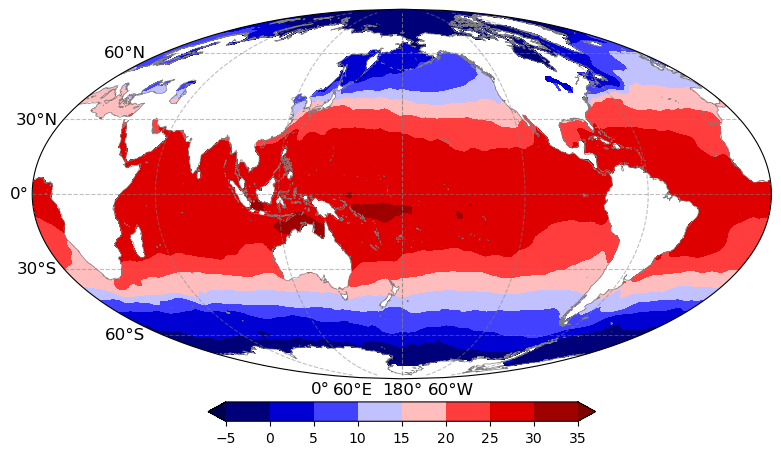

In [3]:
#描画年月のデータを取得
draw_year = 1997
draw_month = 12
draw_var = np.squeeze(sst[:,:,(y==draw_year)*(m==draw_month)])

#描画パラメータの設定
c_lon = 180
vmin, vmax, vint = -5, 35, 5
cm = plt.get_cmap('seismic')

#図の作成と地図投影の設定
fig = plt.figure(figsize=(10, 6))

#モルワイデ図法
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide(central_longitude=c_lon))
#contourf（等値線による塗りつぶし）を用いて水温分布を描画
cs = ax.contourf(lon2, lat2, draw_var,
                 cmap=cm, norm=Normalize(vmin=vmin, vmax=vmax),
                 levels=np.arange(vmin, vmax+vint, vint), extend='both',
                 transform=ccrs.PlateCarree())
#海岸線を細い線で描画
ax.coastlines(lw=0.5, color='gray', resolution='50m')

# モルワイデ図法ではset_xticksが直接使えないのでgridlinesを使用する
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

plt.colorbar(cs, shrink=0.5, orientation='horizontal', pad=0.05)

ax.set_global()

plt.show()